## Survival Analysis: Time Until a ≥5% Daily Increase

In this section, I reframe stock prediction as a survival analysis problem.  
Instead of predicting the exact next-day return, I model the **time until the next ≥5% daily increase** in stock price.

This is useful because in financial markets it is often important not only to know **whether** a strong move may happen, but also **how soon** it may happen.  
I use one pooled survival model across all stocks, then evaluate performance for each stock separately.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

### Prepare the dataset

The dataset already contains lagged return, volatility, and volume-based features, so I use them directly.  
I also create log-transformed volume to reduce scale effects.

To avoid data leakage, I split the data by date first and then create survival targets separately for train and test periods.

In [3]:
data_path = Path("../01_data/raw/df_eda.csv")
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (19836, 17)


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Target_Return_1d,Weekday,Month
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412384,493729600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,0.001729,Monday,January
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423470,601904800,AAPL,0.001729,NaN,NaN,NaN,NaN,0.219098,-0.015906,Tuesday,January
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321297,552160000,AAPL,-0.015906,NaN,NaN,NaN,NaN,-0.082646,-0.001849,Wednesday,January
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL,-0.001849,-0.016028,NaN,NaN,NaN,-0.135882,0.006648,Thursday,January
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351556,447610800,AAPL,0.006648,-0.011195,NaN,NaN,NaN,-0.061871,-0.008821,Friday,January


In [4]:
df_surv = df.copy()

df_surv["Date"] = pd.to_datetime(df_surv["Date"])
df_surv = df_surv.sort_values(["Ticker", "Date"]).reset_index(drop=True)

df_surv["Log_Volume"] = np.log1p(df_surv["Volume"])

numeric_features = [
    "Return_1d",
    "Return_3d",
    "Return_5d",
    "Volatility_5d",
    "Volatility_20d",
    "Volume_Change_1d",
    "Log_Volume"
]

categorical_features = ["Ticker", "Weekday", "Month"]

base_cols = ["Date", "Target_Return_1d"] + numeric_features + categorical_features
df_surv = df_surv[base_cols].copy()

# Keep only rows where features and next-day return target are available
df_surv = df_surv.dropna(subset=numeric_features + ["Target_Return_1d"]).reset_index(drop=True)

df_surv.head()

,Date,Target_Return_1d,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Log_Volume,Ticker,Weekday,Month
0,2010-02-02,0.017206,0.005803,-0.017211,-0.048946,0.026783,0.022815,-0.068723,20.364220,AAPL,Tuesday,February
1,2010-02-03,-0.036039,0.017206,0.037332,-0.041610,0.028353,0.023283,-0.118873,20.237666,AAPL,Wednesday,February
2,2010-02-04,0.017756,-0.036039,-0.013762,-0.036329,0.026866,0.024267,0.231298,20.445735,AAPL,Thursday,February
3,2010-02-05,-0.006856,0.017756,-0.002042,0.017703,0.022736,0.024767,0.122292,20.561108,AAPL,Friday,February
4,2010-02-08,0.010663,-0.006856,-0.025649,-0.003132,0.022304,0.024661,-0.437531,19.985688,AAPL,Monday,February


### Split data chronologically

I use a time-based split so that the model is trained on earlier observations and evaluated on later ones.  
This better reflects a realistic forecasting setup.

In [5]:
unique_dates = np.sort(df_surv["Date"].unique())
split_idx = int(len(unique_dates) * 0.8)
split_date = unique_dates[split_idx]

train_raw = df_surv[df_surv["Date"] < split_date].copy()
test_raw = df_surv[df_surv["Date"] >= split_date].copy()

print("Split date:", pd.to_datetime(split_date).date())
print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)

Split date: 2023-01-03
Train shape: (15661, 12)
Test shape: (4070, 12)


### Create survival target

The event is defined as a **next-day return of at least 5%**.

For each row, I calculate:

- **Event_Next_5pct**: whether the next day already reaches the 5% threshold
- **Duration**: number of trading days until the next such event
- **Observed**: whether the event is observed in the available period or censored

Rows with no future 5% event within the given time window are treated as **right-censored**.

In [6]:
def build_survival_dataset(data, threshold=0.05):
    def per_ticker(group):
        g = group.sort_values("Date").copy()

        event_now = (g["Target_Return_1d"] >= threshold).astype(int).to_numpy()
        n = len(g)

        durations = np.zeros(n, dtype=int)
        observed = np.zeros(n, dtype=int)

        next_event_idx = None

        for i in range(n - 1, -1, -1):
            if event_now[i] == 1:
                next_event_idx = i
                durations[i] = 1
                observed[i] = 1
            else:
                if next_event_idx is None:
                    durations[i] = n - i
                    observed[i] = 0
                else:
                    durations[i] = next_event_idx - i + 1
                    observed[i] = 1

        g["Event_Next_5pct"] = event_now
        g["Duration"] = durations
        g["Observed"] = observed

        return g

    return (
        data.groupby("Ticker", group_keys=False)
        .apply(per_ticker)
        .reset_index(drop=True)
    )

full_surv = build_survival_dataset(df_surv)
train_surv = build_survival_dataset(train_raw)
test_surv = build_survival_dataset(test_raw)

full_surv.head()

C:\Users\Nitro\AppData\Local\Temp\ipykernel_18812\1512182073.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(per_ticker)
C:\Users\Nitro\AppData\Local\Temp\ipykernel_18812\1512182073.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(per_ticker)
C:\Users\Nitro\AppData\Local\Temp\ipykernel_18812\1512182073.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior 

,Date,Target_Return_1d,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Log_Volume,Ticker,Weekday,Month,Event_Next_5pct,Duration,Observed
0,2010-02-02,0.017206,0.005803,-0.017211,-0.048946,0.026783,0.022815,-0.068723,20.364220,AAPL,Tuesday,February,0,54,1
1,2010-02-03,-0.036039,0.017206,0.037332,-0.041610,0.028353,0.023283,-0.118873,20.237666,AAPL,Wednesday,February,0,53,1
2,2010-02-04,0.017756,-0.036039,-0.013762,-0.036329,0.026866,0.024267,0.231298,20.445735,AAPL,Thursday,February,0,52,1
3,2010-02-05,-0.006856,0.017756,-0.002042,0.017703,0.022736,0.024767,0.122292,20.561108,AAPL,Friday,February,0,51,1
4,2010-02-08,0.010663,-0.006856,-0.025649,-0.003132,0.022304,0.024661,-0.437531,19.985688,AAPL,Monday,February,0,50,1


### Check event frequency and censoring

Before fitting the model, I inspect how often the event happens and how much censoring is present.  
This is important because a 5% next-day increase is relatively rare for large-cap stocks.

In [7]:
event_summary = (
    full_surv.groupby("Ticker")
    .agg(
        Rows=("Ticker", "size"),
        Event_Rate=("Event_Next_5pct", "mean"),
        Observed_Rate=("Observed", "mean"),
        Median_Duration=("Duration", "median")
    )
    .reset_index()
)

event_summary

,Ticker,Rows,Event_Rate,Observed_Rate,Median_Duration
0,AAPL,4066,0.009592,0.959420,82.0
1,AMZN,4066,0.015248,0.974422,50.0
2,GOOGL,4066,0.009100,0.999508,85.0
3,META,3467,0.021633,0.999423,50.0
4,MSFT,4066,0.007132,0.943187,113.0


### Kaplan-Meier curves

As a descriptive baseline, I plot Kaplan-Meier survival curves for each stock.  
These show the probability that a 5% next-day increase has **not yet occurred** after a given number of trading days.

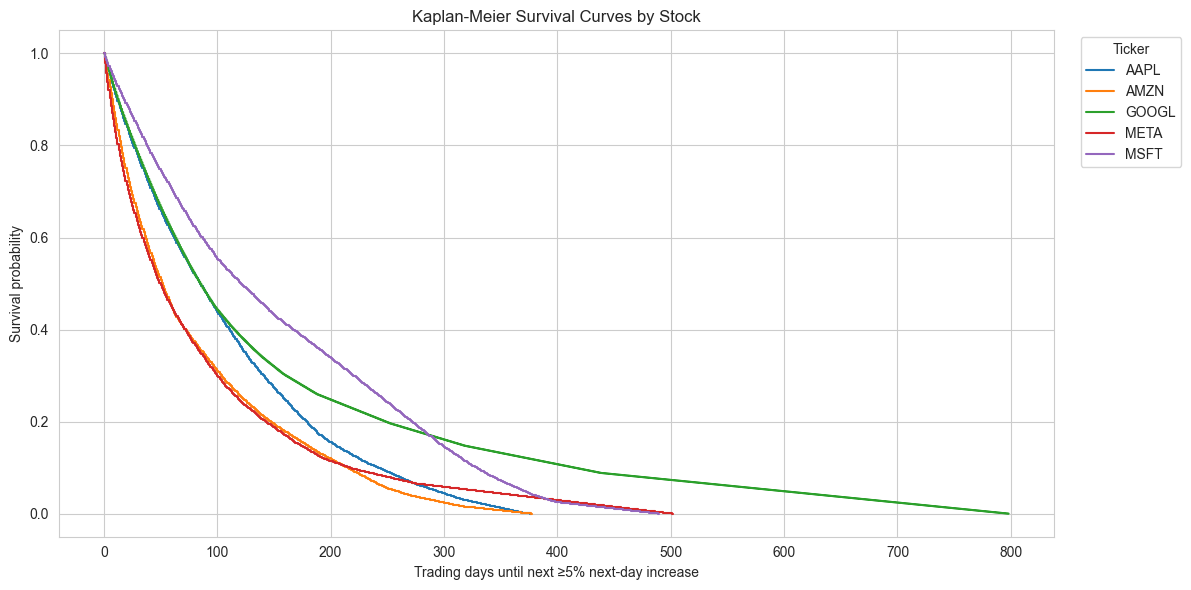

In [8]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(12, 6))

for ticker, temp in full_surv.groupby("Ticker"):
    kmf.fit(
        durations=temp["Duration"],
        event_observed=temp["Observed"],
        label=ticker
    )
    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan-Meier Survival Curves by Stock")
plt.xlabel("Trading days until next ≥5% next-day increase")
plt.ylabel("Survival probability")
plt.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Prepare data for the Cox proportional hazards model

I use a pooled Cox proportional hazards model as a baseline survival model.  
It estimates how the features affect the **hazard**, meaning the chance that the event happens sooner rather than later.

Ticker, weekday, and month are included as categorical variables, so the model remains shared across all stocks while still accounting for differences between them.

In [9]:
model_features = numeric_features + categorical_features

X_train = pd.get_dummies(
    train_surv[model_features],
    columns=categorical_features,
    drop_first=True
)

X_test = pd.get_dummies(
    test_surv[model_features],
    columns=categorical_features,
    drop_first=True
)

# Align columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# Scale numeric columns
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

cox_train = pd.concat(
    [X_train.reset_index(drop=True),
     train_surv[["Duration", "Observed"]].reset_index(drop=True)],
    axis=1
)

cox_test = pd.concat(
    [X_test.reset_index(drop=True),
     test_surv[["Duration", "Observed"]].reset_index(drop=True)],
    axis=1
)

cox_train.head()

,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Log_Volume,Ticker_AMZN,Ticker_GOOGL,Ticker_META,Ticker_MSFT,Weekday_Monday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday,Month_August,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,Duration,Observed
0,0.250882,-0.607488,-1.278056,0.945179,0.604491,-0.314869,2.699478,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,54,1
1,0.836581,1.054892,-1.102672,1.084639,0.657469,-0.436010,2.561649,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,53,1
2,-1.898256,-0.502375,-0.976396,0.952568,0.768723,0.409848,2.788255,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,52,1
3,0.864801,-0.145172,0.315398,0.585542,0.825220,0.146539,2.913907,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,51,1
4,-0.399319,-0.864657,-0.182733,0.547189,0.813318,-1.205746,2.287222,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,50,1


### Fit the Cox model

Positive coefficients indicate a higher hazard, meaning the 5% increase is expected to happen sooner.  
Negative coefficients indicate a lower hazard, meaning the event is expected to take longer.

In [10]:
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_train, duration_col="Duration", event_col="Observed")

cph.summary[["coef", "exp(coef)", "p"]].sort_values("coef", ascending=False).head(15)

,coef,exp(coef),p
covariate,,,
Volatility_20d,0.345444,1.412617,6.038467e-238
Month_July,0.148741,1.160372,4.399681e-06
Ticker_AMZN,0.136717,1.146504,8.145334e-09
Month_September,0.111643,1.118114,6.559998e-04
Ticker_META,0.093037,1.097503,2.840407e-03
Month_October,0.091637,1.095966,4.240757e-03
Log_Volume,0.057452,1.059135,1.039081e-07
Volatility_5d,0.051280,1.052618,7.194310e-08
Month_June,0.029897,1.030348,3.546057e-01


### Evaluate the model

I use the **concordance index (C-index)** to evaluate the survival model.  
This measures how well the model ranks observations by time to event.

A higher C-index means the model is better at distinguishing which observations are likely to experience the event sooner.

In [11]:
test_eval = test_surv.reset_index(drop=True).copy()

# Higher partial hazard = event expected sooner
test_eval["Risk_Score"] = cph.predict_partial_hazard(X_test).values.flatten()

# For c-index, higher predicted score should mean longer time,
# so I use negative risk score
overall_cindex = concordance_index(
    event_times=test_eval["Duration"],
    predicted_scores=-test_eval["Risk_Score"],
    event_observed=test_eval["Observed"]
)

print(f"Overall test C-index: {overall_cindex:.4f}")

Overall test C-index: 0.5483


In [12]:
def safe_cindex(group):
    try:
        return concordance_index(
            event_times=group["Duration"],
            predicted_scores=-group["Risk_Score"],
            event_observed=group["Observed"]
        )
    except Exception:
        return np.nan

stock_results = (
    test_eval.groupby("Ticker")
    .apply(lambda g: pd.Series({
        "Rows": len(g),
        "Event_Rate": g["Event_Next_5pct"].mean(),
        "Observed_Rate": g["Observed"].mean(),
        "Median_Actual_Duration": g["Duration"].median(),
        "C_Index": safe_cindex(g)
    }))
    .reset_index()
    .sort_values("C_Index", ascending=False)
)

stock_results

C:\Users\Nitro\AppData\Local\Temp\ipykernel_18812\3688762318.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,Ticker,Rows,Event_Rate,Observed_Rate,Median_Actual_Duration,C_Index
4,MSFT,814.0,0.003686,0.716216,157.5,0.597221
1,AMZN,814.0,0.011057,0.872236,52.5,0.588280
0,AAPL,814.0,0.006143,0.797297,100.5,0.514529
3,META,814.0,0.014742,0.997543,52.0,0.467632
2,GOOGL,814.0,0.013514,0.997543,48.0,0.427258


### Visualize survival model performance by stock

To make the results easier to compare, I visualize the C-index for each stock separately.

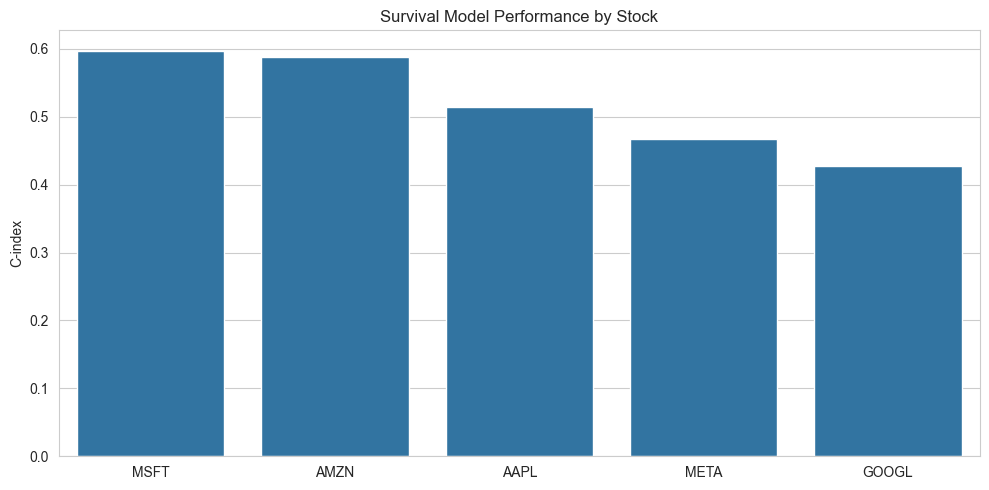

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(data=stock_results, x="Ticker", y="C_Index")
plt.title("Survival Model Performance by Stock")
plt.xlabel("")
plt.ylabel("C-index")
plt.tight_layout()
plt.show()

### Survival analysis conclusions

This survival analysis framework models not only whether a large positive move happens, but also how soon it happens.  
The Kaplan-Meier curves provide a descriptive view of event timing across stocks, while the Cox model gives a pooled, feature-based estimate of time to event.

Because a 5% next-day increase is rare for large-cap stocks, this is a difficult prediction task and censoring is expected to be relatively high.  
Therefore, the model is likely more useful for ranking observations by relative event timing than for highly precise duration prediction.

### Possible improvements

This survival analysis could be improved by:

- adding richer lagged and rolling features
- including broader market signals such as index returns
- tuning the Cox penalizer
- trying more flexible survival models such as Random Survival Forests
- testing different event thresholds, since 5% next-day gains may be too rare